### Step 1: Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2 
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [4]:
from imblearn.over_sampling import RandomOverSampler

In [6]:
from xgboost import XGBClassifier

### Step 2: Load Dataset

In [7]:
df = pd.read_csv('./data/parkinson_disease.csv')

In [8]:
df.shape

(756, 755)

In [9]:
df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


### Step 3: Exploaring Data

Basic Info

In [20]:
pd.set_option('display.max_rows', 20)

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,756.0,125.500000,72.793721,0.000000,62.750000,125.500000,188.250000,251.00000
gender,756.0,0.515873,0.500079,0.000000,0.000000,1.000000,1.000000,1.00000
PPE,756.0,0.746284,0.169294,0.041551,0.762833,0.809655,0.834315,0.90766
DFA,756.0,0.700414,0.069718,0.543500,0.647053,0.700525,0.754985,0.85264
RPDE,756.0,0.489058,0.137442,0.154300,0.386537,0.484355,0.586515,0.87123
...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,756.0,12.375335,16.341665,1.628700,3.114375,4.741450,12.201325,73.53220
tqwt_kurtosisValue_dec_34,756.0,14.799230,15.722502,1.861700,3.665925,6.725700,21.922050,62.00730
tqwt_kurtosisValue_dec_35,756.0,14.751559,14.432979,1.955900,3.741275,7.334250,22.495175,57.54430
tqwt_kurtosisValue_dec_36,756.0,31.481110,34.230991,2.364000,3.948750,10.637250,61.125325,156.42370


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [25]:
df.isnull().sum().sum()

0

Feature Distribution

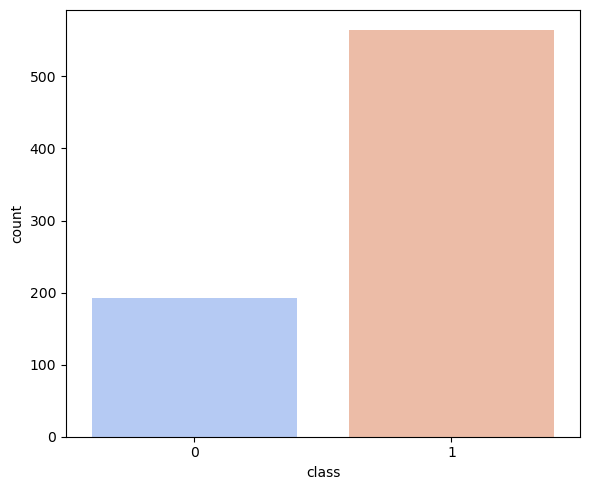

In [30]:
plt.figure(figsize=(6, 5))
sns.countplot(x='class', data=df, palette='coolwarm')
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Values

In [31]:
df.dropna(axis=0, ignore_index=True, inplace=True)

Aggregate Data

In [33]:
df = df.groupby('id').mean().reset_index()

Remove Highly Correlated Features

In [52]:
def drop_correlated_features_keep_target_relevant(
    X: pd.DataFrame,
    y: pd.Series,
    threshold: float = 0.9,
    corr_method: str = "pearson",
    target_corr_method: str = None
):
    """
    删除彼此高度相关的特征，但优先保留与目标变量 y 相关性更强的特征

    Parameters
    ----------
    X : pd.DataFrame
        特征 DataFrame
    y : pd.Series
        目标变量
    threshold : float, default=0.9
        特征之间的相关系数阈值
    corr_method : str, default="pearson"
        特征-特征 相关性计算方法
    target_corr_method : str, optional
        特征-y 的相关性计算方法，默认与 corr_method 一致

    Returns
    -------
    X_reduced : pd.DataFrame
        处理后的特征 DataFrame
    dropped_features : list
        被删除的特征列表
    """

    if target_corr_method is None:
        target_corr_method = corr_method

    # 只使用数值特征
    X_numeric = X.select_dtypes(include=[np.number])

    # 特征-特征相关性
    feature_corr = X_numeric.corr(method=corr_method).abs()

    # 特征-y 相关性
    target_corr = X_numeric.apply(
        lambda col: col.corr(y, method=target_corr_method)
    ).abs()

    # 上三角
    upper_triangle = feature_corr.where(
        np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
    )

    dropped_features = set()

    for col in upper_triangle.columns:
        if col in dropped_features:
            continue

        high_corr_features = upper_triangle.index[
            upper_triangle[col] > threshold
        ].tolist()

        for other_col in high_corr_features:
            if other_col in dropped_features:
                continue

            # 比较与 y 的相关性
            if target_corr[col] >= target_corr[other_col]:
                dropped_features.add(other_col)
            else:
                dropped_features.add(col)
                break

    X_reduced = X.drop(columns=list(dropped_features))

    return pd.X_reduced, list(dropped_features)

In [64]:
features, drop_list = drop_correlated_features_keep_target_relevant(df.iloc[:,:-1], df.iloc[:, -1], 0.7)

In [65]:
print(f'Delete {len(drop_list)} features, there are still {len(df.columns)-len(drop_list)} features remaining')

Delete 528 features, there are still 227 features remaining


Normalization

In [67]:
scaler = MinMaxScaler()

In [68]:
for col in features.columns:
    if col not in ['gender']:
        features[col] = scaler.fit_transform(features[[col]])

Feature Selection

In [69]:
selector = SelectKBest(chi2, k=30)

In [70]:
selector.fit(features, df['class'])

,score_func,<function chi...002053746D000>
,k,30


In [74]:
features = features.loc[:, selector.get_support()]

Heat Map

<Axes: >

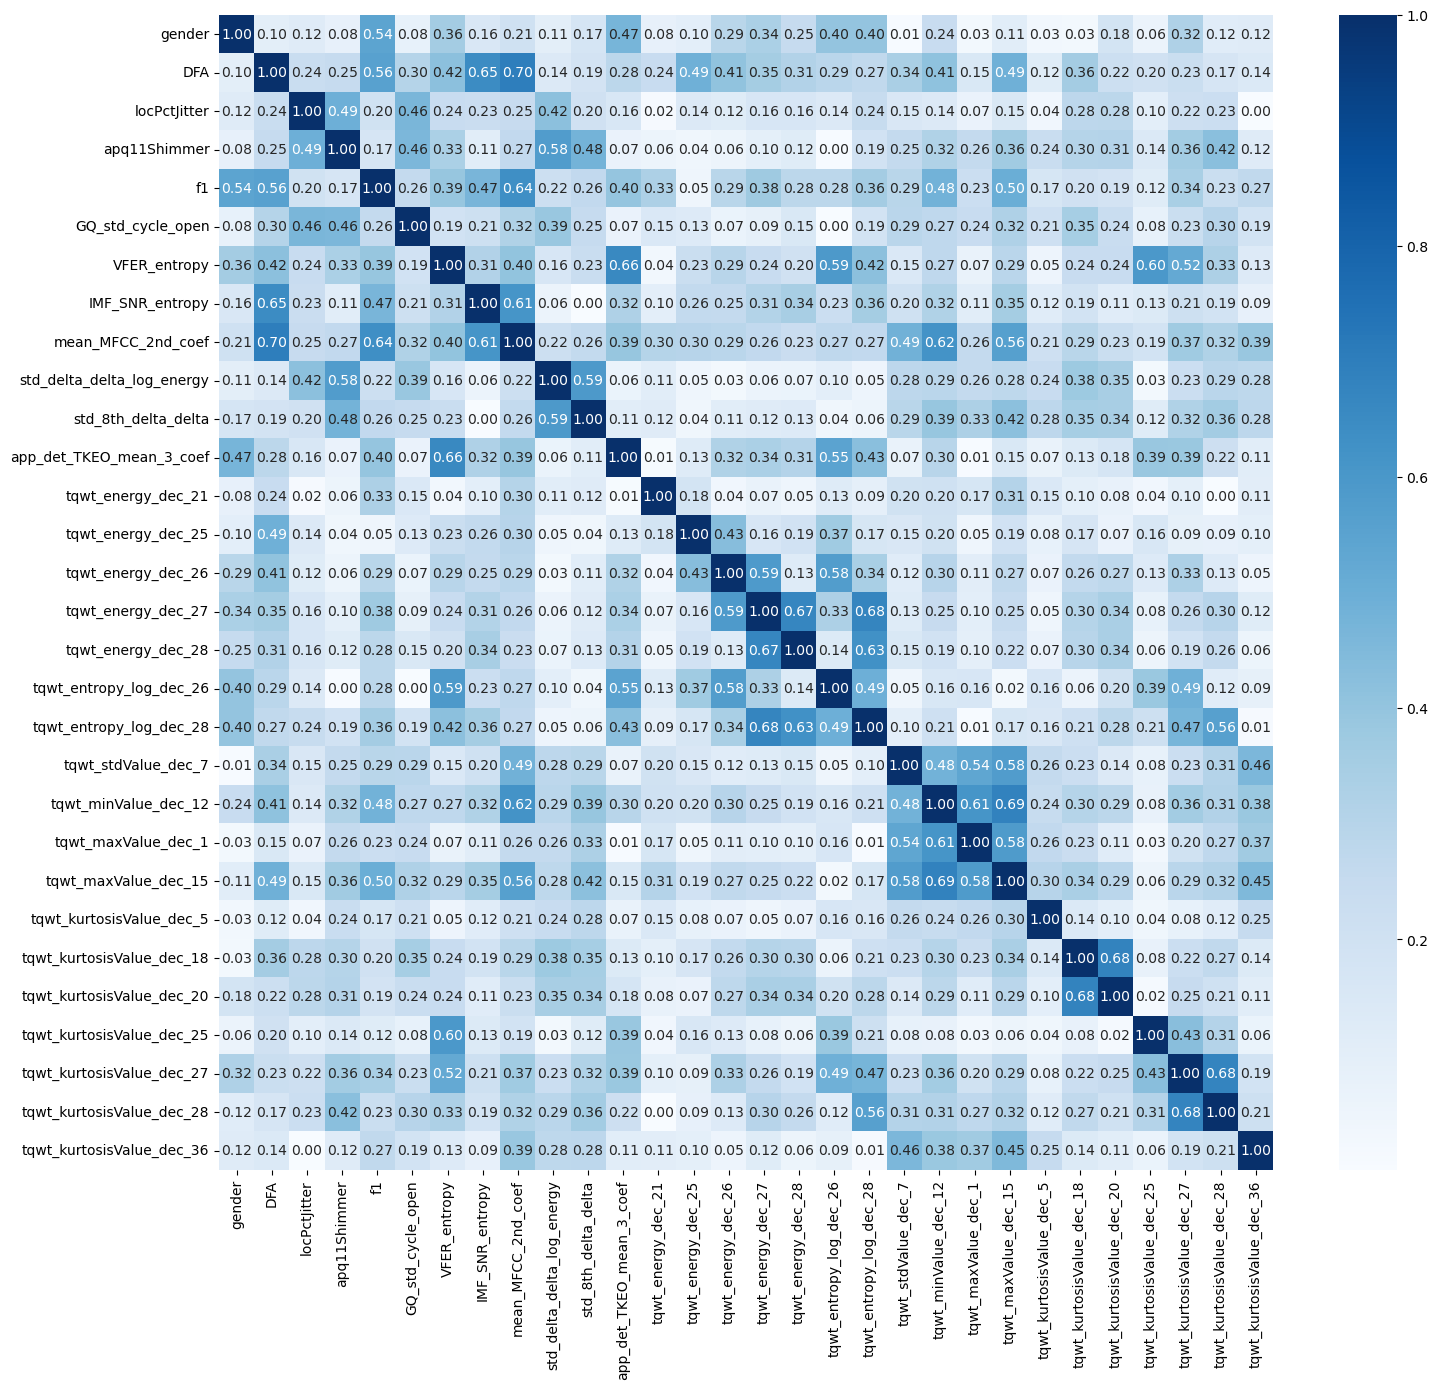

In [77]:
plt.figure(figsize=(17, 15))
sns.heatmap(
    features.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)

### Step 5: Preparing Data

Preparing Features and Target

In [83]:
target = df['class']

Split Data

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Balanced Data

In [85]:
ros = RandomOverSampler(random_state=42)

In [86]:
X_train, y_train = ros.fit_resample(X_train, y_train)

### Step 6: Model Training and Evaluation

In [88]:
models = [
    LogisticRegression(class_weight='balanced'),
    XGBClassifier(),
    SVC(probability=True)
]

In [89]:
for model in models:
    model.fit(X_train, y_train)
    print(f"{model.__class__.__name__}:")
    train_preds = model.predict(X_train)
    print('Training Accuracy:', metrics.roc_auc_score(y_train, train_preds))

    test_preds = model.predict(X_test)
    print('Validation Accuracy:', metrics.roc_auc_score(y_test, test_preds))
    print('-' * 20)

LogisticRegression:
Training Accuracy: 0.7814569536423841
Validation Accuracy: 0.7847490347490347
--------------------
XGBClassifier:
Training Accuracy: 1.0
Validation Accuracy: 0.7722007722007722
--------------------
SVC:
Training Accuracy: 0.9006622516556292
Validation Accuracy: 0.7847490347490347
--------------------


### Step 7: Analyzing Model Performance

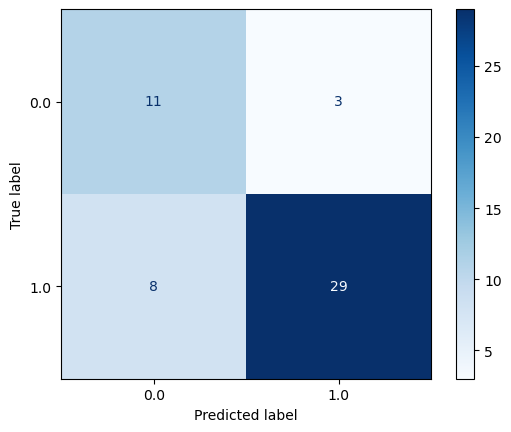

In [92]:
metrics.ConfusionMatrixDisplay.from_estimator(models[0], X_test, y_test, cmap=plt.cm.Blues)

In [93]:
print(metrics.classification_report(y_test, models[0].predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.58      0.79      0.67        14
         1.0       0.91      0.78      0.84        37

    accuracy                           0.78        51
   macro avg       0.74      0.78      0.75        51
weighted avg       0.82      0.78      0.79        51

